# Jeddah Walking Trajectory — One-Step-Ahead Position Prediction

Predicts the **next GPS position** (latitude, longitude) from the **previous K positions** using Mobisense walking-mode data.

**Models:** Naive Baseline, Linear Regression, Random Forest, Extra Trees, LSTM (PyTorch)

**Rules:**
- Always uses REAL past positions as input (no recursive prediction)
- Time order is never shuffled
- Sliding windows never cross different CSV files

## 1. Imports & Configuration

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
%matplotlib inline

# ── CONFIGURATION — edit these as needed ──
DATA_DIR   = "walk_jeddah"        # folder containing CSV files
LAT_COL    = "Latitude"           # column name for latitude
LON_COL    = "Longitude"          # column name for longitude
TIME_COL   = "Time"               # column name for timestamp (set to None if unavailable)
K          = 5                    # number of past positions used as input
TRAIN_RATIO = 0.80                # first 80% train / last 20% test
LSTM_EPOCHS = 50
LSTM_BATCH  = 32
OUTPUT_DIR  = "results"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 2. Helper Functions

In [2]:
def load_trajectories(data_dir, lat_col, lon_col, time_col):
    """Load every CSV in data_dir and return a list of (filename, DataFrame)
    tuples, each containing deduplicated (lat, lon) trajectory points."""
    csv_paths = sorted(glob.glob(os.path.join(data_dir, "*.csv")))
    if not csv_paths:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")

    trajectories = []
    for path in csv_paths:
        fname = os.path.basename(path)
        df = pd.read_csv(path, low_memory=False)

        print(f"\n{'='*60}")
        print(f"File: {fname}  — raw rows: {len(df)}")
        print(f"Columns ({len(df.columns)}):")
        for i, c in enumerate(df.columns):
            print(f"  [{i:>2}] {c}")

        df = df.dropna(subset=[lat_col, lon_col])
        print(f"Rows with valid {lat_col}/{lon_col}: {len(df)}")

        if time_col and time_col in df.columns:
            df = df.sort_values(time_col).reset_index(drop=True)

        coords = df[[lat_col, lon_col]].values
        # Remove consecutive duplicates (same GPS fix repeated on many rows)
        mask = np.ones(len(coords), dtype=bool)
        for i in range(1, len(coords)):
            if coords[i, 0] == coords[i-1, 0] and coords[i, 1] == coords[i-1, 1]:
                mask[i] = False
        traj = pd.DataFrame(coords[mask], columns=["lat", "lon"])
        print(f"Unique consecutive positions (trajectory points): {len(traj)}")
        trajectories.append((fname, traj))

    return trajectories


def make_windows(traj_df, k):
    """Create sliding windows from a single trajectory.
    Returns:
        X_seq  : (N, K, 2)  — sequential input for LSTM
        X_flat : (N, K*2)   — flattened input for tree/linear models
        Y      : (N, 2)     — target (lat, lon)
    """
    vals = traj_df[["lat", "lon"]].values
    X_seq, Y = [], []
    for i in range(k, len(vals)):
        X_seq.append(vals[i - k : i])
        Y.append(vals[i])
    X_seq = np.array(X_seq)
    Y = np.array(Y)
    X_flat = X_seq.reshape(len(X_seq), -1)
    return X_seq, X_flat, Y


def haversine_np(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance in metres."""
    R = 6_371_000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def evaluate(y_true, y_pred, label=""):
    """Compute MAE, RMSE (lat/lon) and haversine-based errors."""
    mae_lat  = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mae_lon  = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
    rmse_lat = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_lon = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))

    dist = haversine_np(y_true[:, 0], y_true[:, 1],
                        y_pred[:, 0], y_pred[:, 1])

    print(f"\n--- {label} ---")
    print(f"  MAE  lat: {mae_lat:.8f}°   lon: {mae_lon:.8f}°")
    print(f"  RMSE lat: {rmse_lat:.8f}°   lon: {rmse_lon:.8f}°")
    print(f"  Haversine (m)  mean: {dist.mean():.2f}  "
          f"median: {np.median(dist):.2f}  "
          f"p90: {np.percentile(dist, 90):.2f}")

    return {
        "model": label,
        "MAE_lat": mae_lat, "MAE_lon": mae_lon,
        "RMSE_lat": rmse_lat, "RMSE_lon": rmse_lon,
        "haversine_mean_m": dist.mean(),
        "haversine_median_m": np.median(dist),
        "haversine_p90_m": np.percentile(dist, 90),
    }, dist


class LSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 2)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h.squeeze(0))


class HaversineLoss(nn.Module):
    """Differentiable mean haversine distance (metres) on normalised lat/lon.
    Inverse-transforms predictions & targets back to degrees before computing."""
    def __init__(self, scaler_y):
        super().__init__()
        scale = torch.tensor(scaler_y.data_range_, dtype=torch.float32)
        mn    = torch.tensor(scaler_y.data_min_,   dtype=torch.float32)
        self.register_buffer("scale", scale)
        self.register_buffer("mn", mn)

    def forward(self, pred_n, target_n):
        pred   = pred_n * self.scale + self.mn
        target = target_n * self.scale + self.mn
        R = 6_371_000.0
        lat1 = target[:, 0] * (3.141592653589793 / 180.0)
        lon1 = target[:, 1] * (3.141592653589793 / 180.0)
        lat2 = pred[:, 0]   * (3.141592653589793 / 180.0)
        lon2 = pred[:, 1]   * (3.141592653589793 / 180.0)
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = torch.sin(dlat / 2) ** 2 + \
            torch.cos(lat1) * torch.cos(lat2) * torch.sin(dlon / 2) ** 2
        a = torch.clamp(a, min=0.0, max=1.0)
        dist = R * 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))
        return dist.mean()


class ScaledMSELoss(nn.Module):
    def __init__(self, weight):
        super().__init__()
        self.weight = weight
    def forward(self, pred, target):
        return self.weight * nn.functional.mse_loss(pred, target)

print("Helper functions defined.")

Helper functions defined.


## 3. Load Data & Print Column Names

In [3]:
trajectories = load_trajectories(DATA_DIR, LAT_COL, LON_COL, TIME_COL)
print(f"\nLoaded {len(trajectories)} trajectory files.")


File: walk_jeddah_069.csv  — raw rows: 69111
Columns (78):
  [ 0] Time
  [ 1] Longitude
  [ 2] Latitude
  [ 3] Velocity
  [ 4] RSRP/antenna port - 1
  [ 5] RSRP/antenna port - 2
  [ 6] RSRP/antenna port - 3
  [ 7] RSRP/antenna port - 4
  [ 8] RSRP/antenna port - 5
  [ 9] RSRP/antenna port - 6
  [10] RSRP/antenna port - 7
  [11] RSRP/antenna port - 8
  [12] RSRP/antenna port - 9
  [13] RSRP/antenna port - 10
  [14] E-UTRAN carrier RSSI/antenna port - 1
  [15] E-UTRAN carrier RSSI/antenna port - 2
  [16] E-UTRAN carrier RSSI/antenna port - 3
  [17] E-UTRAN carrier RSSI/antenna port - 4
  [18] E-UTRAN carrier RSSI/antenna port - 5
  [19] E-UTRAN carrier RSSI/antenna port - 6
  [20] E-UTRAN carrier RSSI/antenna port - 7
  [21] E-UTRAN carrier RSSI/antenna port - 8
  [22] E-UTRAN carrier RSSI/antenna port - 9
  [23] E-UTRAN carrier RSSI/antenna port - 10
  [24] RSRQ/antenna port - 1
  [25] RSRQ/antenna port - 2
  [26] RSRQ/antenna port - 3
  [27] RSRQ/antenna port - 4
  [28] RSRQ/antenna p

## 4. Create Sliding Windows & Split Data

In [4]:
all_X_seq, all_X_flat, all_Y = [], [], []
for fname, traj in trajectories:
    if len(traj) <= K:
        print(f"  Skipping {fname}: only {len(traj)} points (need > {K})")
        continue
    xs, xf, y = make_windows(traj, K)
    all_X_seq.append(xs)
    all_X_flat.append(xf)
    all_Y.append(y)
    print(f"  {fname}: {len(y)} windows  "
          f"(X_seq {xs.shape}, X_flat {xf.shape}, Y {y.shape})")

X_seq  = np.concatenate(all_X_seq)
X_flat = np.concatenate(all_X_flat)
Y      = np.concatenate(all_Y)

print(f"\nCombined dataset shapes:")
print(f"  X_seq  (LSTM)   : {X_seq.shape}")
print(f"  X_flat (tree)   : {X_flat.shape}")
print(f"  Y (target)      : {Y.shape}")

# Time-based split: first 80% → train, last 20% → test (no shuffling)
n = len(Y)
split = int(n * TRAIN_RATIO)

X_flat_train, X_flat_test = X_flat[:split], X_flat[split:]
X_seq_train,  X_seq_test  = X_seq[:split],  X_seq[split:]
Y_train,      Y_test      = Y[:split],      Y[split:]

print(f"\nTrain samples: {split}   Test samples: {n - split}")

  walk_jeddah_069.csv: 3010 windows  (X_seq (3010, 5, 2), X_flat (3010, 10), Y (3010, 2))
  walk_jeddah_070.csv: 3676 windows  (X_seq (3676, 5, 2), X_flat (3676, 10), Y (3676, 2))
  walk_jeddah_071.csv: 3710 windows  (X_seq (3710, 5, 2), X_flat (3710, 10), Y (3710, 2))
  walk_jeddah_072.csv: 3152 windows  (X_seq (3152, 5, 2), X_flat (3152, 10), Y (3152, 2))

Combined dataset shapes:
  X_seq  (LSTM)   : (13548, 5, 2)
  X_flat (tree)   : (13548, 10)
  Y (target)      : (13548, 2)

Train samples: 10838   Test samples: 2710


## 5. Train Models

### 5a. Naive Baseline (next = last known position)

In [5]:
results = []
preds = {}

naive_pred = X_seq_test[:, -1, :]
r, _ = evaluate(Y_test, naive_pred, "Naive Baseline (last=next)")
results.append(r)
preds["Naive"] = naive_pred


--- Naive Baseline (last=next) ---
  MAE  lat: 0.00000467°   lon: 0.00000554°
  RMSE lat: 0.00000878°   lon: 0.00001080°
  Haversine (m)  mean: 0.87  median: 0.83  p90: 1.32


### 5b. Linear Regression

In [6]:
lr = LinearRegression()
lr.fit(X_flat_train, Y_train)
lr_pred = lr.predict(X_flat_test)
r, _ = evaluate(Y_test, lr_pred, "Linear Regression")
results.append(r)
preds["LinReg"] = lr_pred


--- Linear Regression ---
  MAE  lat: 0.00000271°   lon: 0.00000341°
  RMSE lat: 0.00000862°   lon: 0.00000916°
  Haversine (m)  mean: 0.51  median: 0.37  p90: 0.81


### 5c. Random Forest

In [7]:
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_flat_train, Y_train)
rf_pred = rf.predict(X_flat_test)
r, _ = evaluate(Y_test, rf_pred, "Random Forest")
results.append(r)
preds["RF"] = rf_pred


--- Random Forest ---
  MAE  lat: 0.00001642°   lon: 0.00001918°
  RMSE lat: 0.00002591°   lon: 0.00002954°
  Haversine (m)  mean: 3.02  median: 2.37  p90: 6.09


### 5d. Extra Trees

In [8]:
et = ExtraTreesRegressor(n_estimators=100, n_jobs=-1, random_state=42)
et.fit(X_flat_train, Y_train)
et_pred = et.predict(X_flat_test)
r, _ = evaluate(Y_test, et_pred, "Extra Trees")
results.append(r)
preds["ExtraTrees"] = et_pred


--- Extra Trees ---
  MAE  lat: 0.00001473°   lon: 0.00001750°
  RMSE lat: 0.00002133°   lon: 0.00002711°
  Haversine (m)  mean: 2.68  median: 2.23  p90: 5.03


### 5e. LSTM Variants — Haversine Loss + Scaled-MSE Sweep

In [9]:
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

scaler_X.fit(X_seq_train.reshape(-1, 2))
scaler_Y.fit(Y_train)

X_seq_train_n = scaler_X.transform(
    X_seq_train.reshape(-1, 2)).reshape(X_seq_train.shape)
X_seq_test_n = scaler_X.transform(
    X_seq_test.reshape(-1, 2)).reshape(X_seq_test.shape)
Y_train_n = scaler_Y.transform(Y_train)

val_cut = int(len(X_seq_train_n) * 0.9)
Xtr_t  = torch.tensor(X_seq_train_n[:val_cut], dtype=torch.float32)
Ytr_t  = torch.tensor(Y_train_n[:val_cut],     dtype=torch.float32)
Xval_t = torch.tensor(X_seq_train_n[val_cut:],  dtype=torch.float32)
Yval_t = torch.tensor(Y_train_n[val_cut:],      dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xtr_t, Ytr_t),
                          batch_size=LSTM_BATCH, shuffle=False)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# Define loss variants to sweep
loss_configs = [
    ("LSTM_Haversine",   HaversineLoss(scaler_Y).to(device)),
    ("LSTM_MSEx10",      ScaledMSELoss(10).to(device)),
    ("LSTM_MSEx100",     ScaledMSELoss(100).to(device)),
    ("LSTM_MSEx1K",      ScaledMSELoss(1_000).to(device)),
    ("LSTM_MSEx10K",     ScaledMSELoss(10_000).to(device)),
    ("LSTM_MSEx100K",    ScaledMSELoss(100_000).to(device)),
]

all_histories = {}

for loss_name, criterion in loss_configs:
    print(f"\n{'─'*50}")
    print(f"Training {loss_name} ...")

    torch.manual_seed(42)
    model = LSTMModel(input_size=2, hidden=64).to(device)
    # Lower learning rate for haversine (large gradient magnitudes)
    lr = 1e-4 if "Haversine" in loss_name else 1e-3
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(1, LSTM_EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(Xtr_t)
        train_losses.append(epoch_loss)

        model.eval()
        with torch.no_grad():
            vp = model(Xval_t.to(device))
            vl = criterion(vp, Yval_t.to(device)).item()
        val_losses.append(vl)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{LSTM_EPOCHS}  "
                  f"train_loss={epoch_loss:.6f}  val_loss={vl:.6f}")

    all_histories[loss_name] = (train_losses, val_losses)

    model.eval()
    with torch.no_grad():
        Xte_t = torch.tensor(X_seq_test_n, dtype=torch.float32).to(device)
        lstm_pred_n = model(Xte_t).cpu().numpy()
    lstm_pred = scaler_Y.inverse_transform(lstm_pred_n)

    if np.isnan(lstm_pred).any():
        print(f"  WARNING: {loss_name} produced NaN predictions — skipping.")
        continue

    r, _ = evaluate(Y_test, lstm_pred, loss_name)
    results.append(r)
    preds[loss_name] = lstm_pred

Training LSTM ...
LSTMModel(
  (lstm): LSTM(2, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
Device: mps
  Epoch   1/50  train_loss=0.048535  val_loss=0.140058
  Epoch  10/50  train_loss=0.009327  val_loss=0.024483
  Epoch  20/50  train_loss=0.001581  val_loss=0.012916
  Epoch  30/50  train_loss=0.001482  val_loss=0.006593
  Epoch  40/50  train_loss=0.001059  val_loss=0.007994
  Epoch  50/50  train_loss=0.000740  val_loss=0.007390

--- LSTM ---
  MAE  lat: 0.00020146°   lon: 0.00116798°
  RMSE lat: 0.00025250°   lon: 0.00119672°
  Haversine (m)  mean: 123.68  median: 118.61  p90: 163.88


## 6. Results Summary

In [10]:
df_results = pd.DataFrame(results)
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
display(df_results)
df_results.to_csv(os.path.join(OUTPUT_DIR, "metrics.csv"), index=False)

RESULTS SUMMARY


,model,MAE_lat,MAE_lon,RMSE_lat,RMSE_lon,haversine_mean_m,haversine_median_m,haversine_p90_m
0,Naive Baseline (last=next),0.000005,0.000006,0.000009,0.000011,0.874240,0.826913,1.317699
1,Linear Regression,0.000003,0.000003,0.000009,0.000009,0.511016,0.372652,0.814280
2,Random Forest,0.000016,0.000019,0.000026,0.000030,3.018925,2.371569,6.088775
3,Extra Trees,0.000015,0.000018,0.000021,0.000027,2.682088,2.229754,5.031689
4,LSTM,0.000201,0.001168,0.000253,0.001197,123.679987,118.605129,163.877754


## 7. Plots

### 7a. LSTM Training Loss (All Variants)

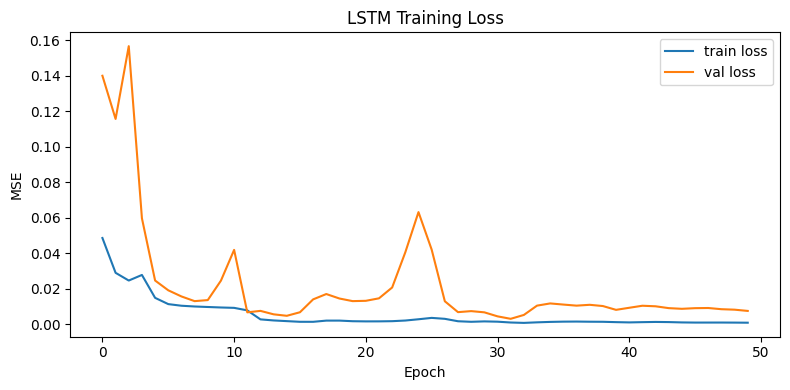

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for loss_name, (tl, vl) in all_histories.items():
    axes[0].plot(tl, label=loss_name, linewidth=0.9)
    axes[1].plot(vl, label=loss_name, linewidth=0.9)
axes[0].set_title("Train Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=6)
axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=6)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "lstm_loss_all_variants.png"), dpi=150)
plt.show()

### 7b. Predicted vs Actual — Latitude

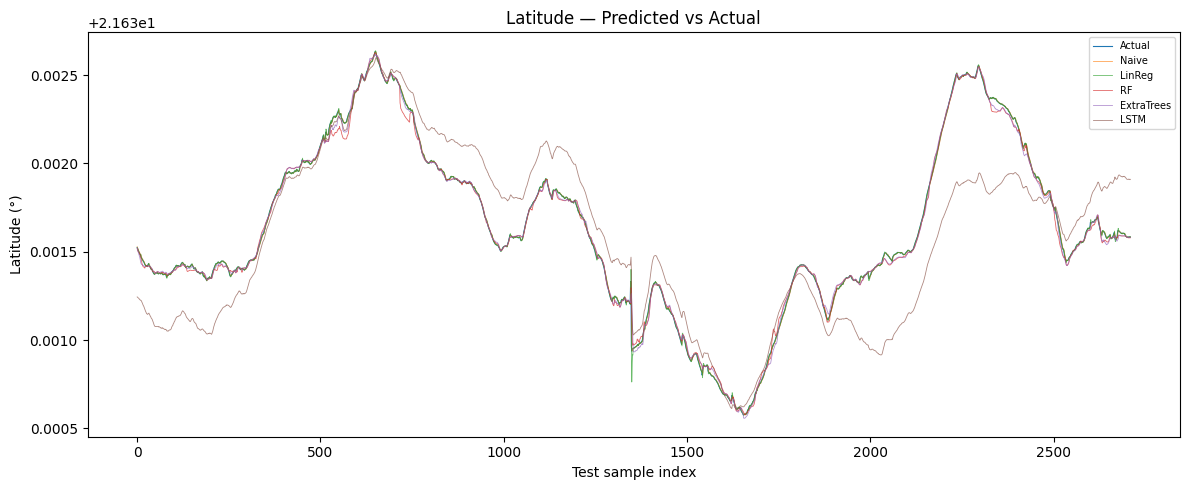

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(Y_test[:, 0], label="Actual", linewidth=0.8)
for name, yp in preds.items():
    ax.plot(yp[:, 0], label=name, linewidth=0.6, alpha=0.7)
ax.set_title("Latitude — Predicted vs Actual")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Latitude (°)")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "pred_vs_actual_lat.png"), dpi=150)
plt.show()

### 7c. Predicted vs Actual — Longitude

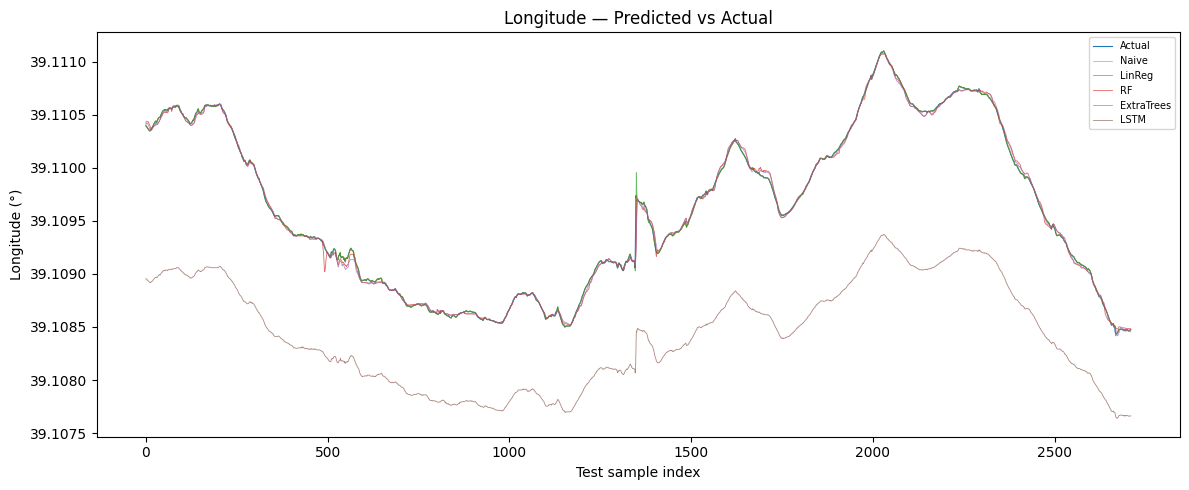

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(Y_test[:, 1], label="Actual", linewidth=0.8)
for name, yp in preds.items():
    ax.plot(yp[:, 1], label=name, linewidth=0.6, alpha=0.7)
ax.set_title("Longitude — Predicted vs Actual")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Longitude (°)")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "pred_vs_actual_lon.png"), dpi=150)
plt.show()

### 7d. Error Histogram (Haversine)

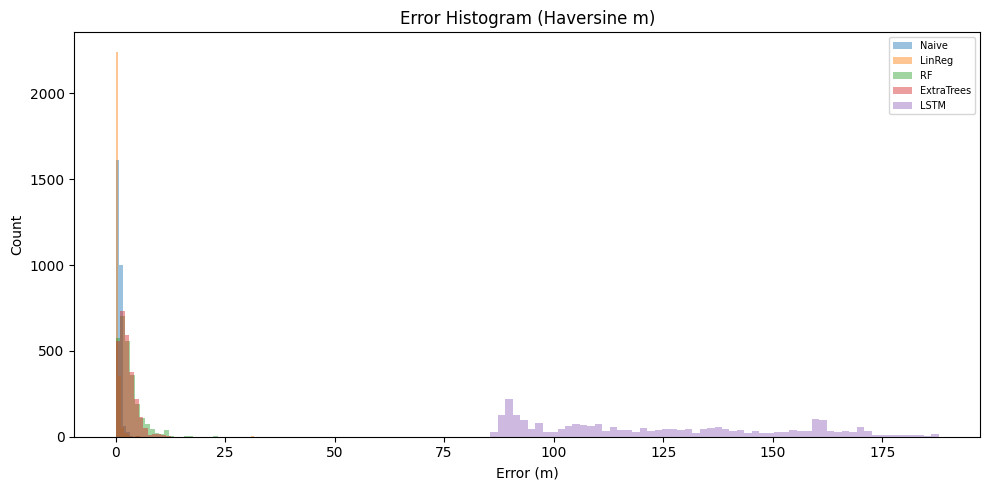

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, yp in preds.items():
    d = haversine_np(Y_test[:, 0], Y_test[:, 1], yp[:, 0], yp[:, 1])
    ax.hist(d, bins=60, alpha=0.45, label=name)
ax.set_title("Error Histogram (Haversine m)")
ax.set_xlabel("Error (m)")
ax.set_ylabel("Count")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "error_histogram.png"), dpi=150)
plt.show()

### 7e. CDF of Haversine Error

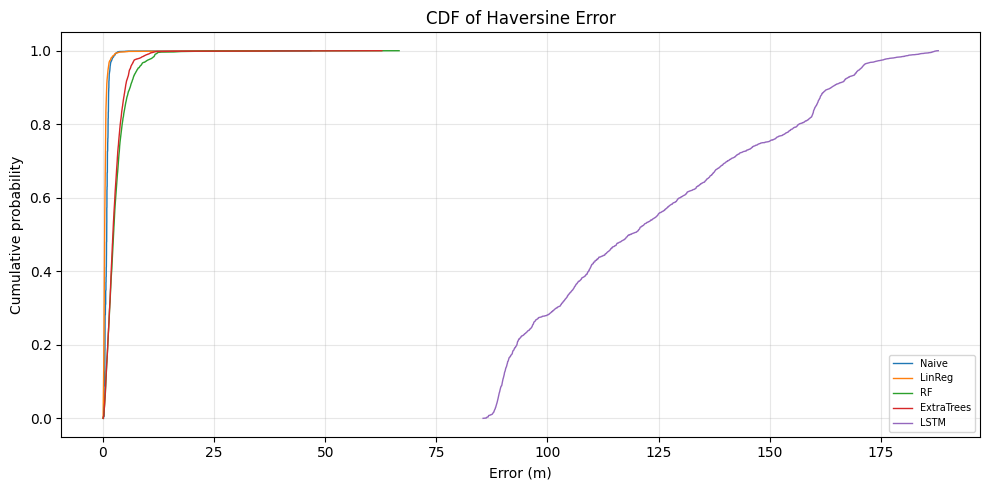

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, yp in preds.items():
    d = haversine_np(Y_test[:, 0], Y_test[:, 1], yp[:, 0], yp[:, 1])
    d_sorted = np.sort(d)
    cdf = np.arange(1, len(d_sorted) + 1) / len(d_sorted)
    ax.plot(d_sorted, cdf, label=name, linewidth=1)
ax.set_title("CDF of Haversine Error")
ax.set_xlabel("Error (m)")
ax.set_ylabel("Cumulative probability")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "error_cdf.png"), dpi=150)
plt.show()

### 7f. Trajectory Map — True vs Predicted

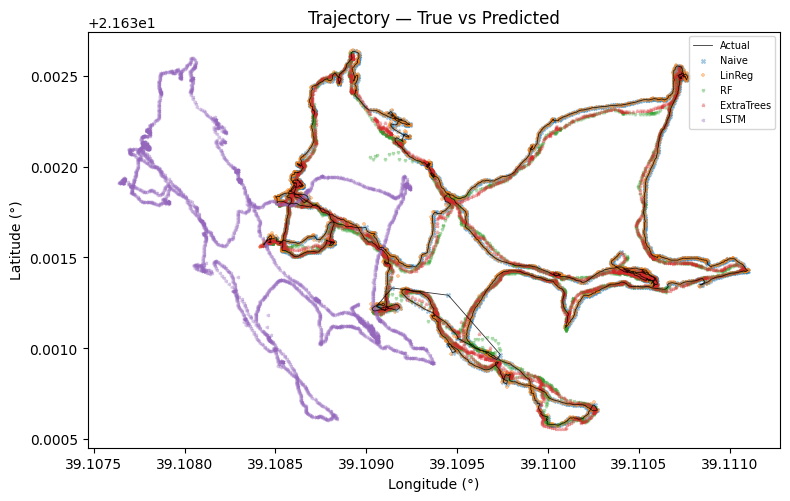

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(Y_test[:, 1], Y_test[:, 0], "k-", linewidth=0.6, label="Actual", alpha=0.8)
markers = ["x", "+", "1", "2", "3"]
for idx, (name, yp) in enumerate(preds.items()):
    ax.scatter(yp[:, 1], yp[:, 0], s=8, alpha=0.4,
               marker=markers[idx % len(markers)], label=name)
ax.set_title("Trajectory — True vs Predicted")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.legend(fontsize=7)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "trajectory_map.png"), dpi=150)
plt.show()

## 8. Save Predictions

In [17]:
for name, yp in preds.items():
    out = pd.DataFrame({
        "actual_lat": Y_test[:, 0], "actual_lon": Y_test[:, 1],
        "pred_lat": yp[:, 0], "pred_lon": yp[:, 1],
    })
    out.to_csv(os.path.join(OUTPUT_DIR, f"predictions_{name}.csv"), index=False)

print(f"All results and predictions saved to '{OUTPUT_DIR}/' directory.")
print("Done.")

All results and predictions saved to 'results/' directory.
Done.
